In [1]:
from gudhi import RipsComplex
from gudhi import DelaunayCechComplex
import numpy as np
import matplotlib.pyplot as plt
from gudhi.representations import PersistenceImage
from collections import defaultdict

from persim import PersistenceImager
import persim.images_weights as weights

In [2]:
def compute_Rips(points, max_edge=10):
    """Compute Rips complex from point cloud."""
    rips = RipsComplex(points=points, max_edge_length=max_edge)
    st = rips.create_simplex_tree(max_dimension=2)
    return st

def divide_filtration(st):
    """Extract simplices and filtration values from simplex tree."""
    simplex_filt_pairs = [(tuple(sorted(s)), f) for s, f in st.get_filtration()]
    list_simplex = [pair[0] for pair in simplex_filt_pairs]
    list_filt = [pair[1] for pair in simplex_filt_pairs]
    return list_simplex, list_filt


def _build_boundary(simplices):
    """Build boundary matrix for a list of simplices in filtration order."""
    sf_to_idx = {s: i for i, s in enumerate(simplices)}
    boundary = []
    for s in simplices:
        if len(s) <= 1:
            boundary.append(set())
        else:
            rows = set()
            for j in range(len(s)):
                face = s[:j] + s[j+1:]
                if face in sf_to_idx:
                    rows.add(sf_to_idx[face])
            boundary.append(rows)
    return boundary


def _reduce_with_V(columns):
    """
    Left-to-right Z/2Z column reduction.
    Returns: R (reduced matrix), low (pivot positions), V (transformation matrix)
    """
    m = len(columns)
    R = [set(col) for col in columns]
    V = [{i} for i in range(m)]
    low = [-1] * m
    pivot_of_row = {}

    for i in range(m):
        while R[i]:
            li = max(R[i])
            if li in pivot_of_row:
                owner = pivot_of_row[li]
                R[i] ^= R[owner]
                V[i] ^= V[owner]
            else:
                pivot_of_row[li] = i
                low[i] = li
                break
        else:
            low[i] = -1
    return R, low, V

In [3]:
def compute_Persistence_barcode(A):
    fil_A = compute_Rips(A)
    fil_A.persistence()

    bar_a0 = fil_A.persistence_intervals_in_dimension(0)
    bar_A0 = [bar for bar in bar_a0 if bar[1] != np.inf]
    bar_a1 = fil_A.persistence_intervals_in_dimension(1)
    bar_A1 = [bar for bar in bar_a1 if bar[1] != np.inf]

    bar0 = []
    for bar in bar_A0:
        if bar[1]-bar[0] > 1e-5:
            bar0.append([bar[0], bar[1]])
    bar1 = []
    for bar in bar_A1:
        if bar[1]-bar[0] > 1e-5:
            bar1.append([bar[0], bar[1]])

    bar_A = {}
    bar_A[0] = np.array(bar0)
    bar_A[1] = np.array(bar1)

    return bar_A

def compute_PIs(barcodes, max_eps=10, px_res=0.1, sigma=0.05, normalization=False):
    keys = barcodes.keys()

    for key in keys:
        if len(barcodes[key]) == 0:
            barcodes[key] = np.zeros((0, 2))

    vector = {}

    # =========================================================================
    # H0 Persistence Image
    # 논문: birth_range=(0, 1), pers_range=(0, max_eps), skew=False
    # =========================================================================
    pers_imager_h0 = PersistenceImager()
    pers_imager_h0.pixel_size = px_res
    pers_imager_h0.birth_range = (0, 1)
    pers_imager_h0.pers_range = (0, max_eps)
    pers_imager_h0.weight = weights.persistence
    pers_imager_h0.weight_params = {'n': 1}
    pers_imager_h0.kernel_params = {'sigma': [[sigma, 0], [0, sigma]]}
    
    bars_h0 = np.array(barcodes[0])
    if len(bars_h0) > 0:
        # H0는 skew=False (이미 birth-persistence 형태로 간주)
        img_h0 = pers_imager_h0.transform(bars_h0, skew=False)
    else:
        img_h0 = np.zeros((int(1/px_res), int(max_eps/px_res)))
    
    # 논문: np.mean(img, axis=0) - birth 축을 따라 평균
    img0_1d = np.mean(img_h0, axis=0)

    # =========================================================================
    # H1 Persistence Image
    # 논문: birth_range=(0, max_eps), pers_range=(0, max_eps/2), skew=True
    # =========================================================================
    pers_imager_h1 = PersistenceImager()
    pers_imager_h1.pixel_size = px_res
    pers_imager_h1.birth_range = (0, max_eps)
    pers_imager_h1.pers_range = (0, max_eps / 2)
    pers_imager_h1.weight = weights.persistence
    pers_imager_h1.weight_params = {'n': 1}
    pers_imager_h1.kernel_params = {'sigma': [[sigma, 0], [0, sigma]]}
    
    bars_h1 = np.array(barcodes[1])
    if len(bars_h1) > 0:
        # H1은 skew=True ((birth, death) → (birth, persistence) 변환)
        img_h1 = pers_imager_h1.transform(bars_h1, skew=True)
    else:
        img_h1 = np.zeros((int(max_eps/px_res), int((max_eps/2)/px_res)))

    # =========================================================================
    # Normalization & Output
    # =========================================================================
    if normalization:
        if np.max(img0_1d) > 0:
            vector[0] = img0_1d / np.max(img0_1d)
        else:
            vector[0] = img0_1d
            
        if np.max(img_h1) > 0:
            vector[1] = img_h1.flatten() / np.max(img_h1)
        else:
            vector[1] = img_h1.flatten()
    else:
        vector[0] = img0_1d
        vector[1] = img_h1.flatten()

    return vector

def visualize_PIs(PIs, max_eps=10, px_res=0.1):
    import matplotlib.pyplot as plt
    
    # H0: shape (100,) - 1D image
    # 논문에서 mean(axis=0)으로 1D가 되었으므로 그대로 plot
    h0_img = PIs[0]
    h0_length = int(max_eps / px_res)  # 100
    
    # H1: shape (5000,) → reshape to (100, 50)
    h1_birth_bins = int(max_eps / px_res)  # 100
    h1_pers_bins = int((max_eps / 2) / px_res)  # 50
    h1_img = PIs[1].reshape((h1_birth_bins, h1_pers_bins))
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # H0 (1D plot)
    axes[0].plot(h0_img, 'b-', linewidth=1.5)
    axes[0].fill_between(range(len(h0_img)), h0_img, alpha=0.3)
    axes[0].set_title(f'H0 Persistence Image (1D)\nLength: {h0_length}')
    axes[0].set_xlabel('Persistence (Bin Index)')
    axes[0].set_ylabel('Intensity')
    axes[0].set_xlim([0, h0_length])
    axes[0].grid(True, alpha=0.3)
    
    # H1 (2D image)
    im = axes[1].imshow(h1_img.T, cmap='hot', origin='lower', aspect='auto')
    axes[1].set_title(f'H1 Persistence Image (2D)\nResolution: ({h1_birth_bins}, {h1_pers_bins})')
    axes[1].set_xlabel('Birth (Bin Index)')
    axes[1].set_ylabel('Persistence (Bin Index)')
    plt.colorbar(im, ax=axes[1], label='Intensity')
    
    plt.tight_layout()
    plt.show()

In [5]:
def compute_all_barcodes(A, B, max_edge=10):
    total = np.concatenate([A, B], axis=0)
    a = len(A)

    st = compute_Rips(total, max_edge = 10)
    simplices, filt = divide_filtration(st)
    m = len(simplices)

    # ── L / K\L 분류 ──────────────────────────────────────────────
    in_L        = [all(v < a for v in s) for s in simplices]
    idx_L       = [i for i, b in enumerate(in_L) if b]
    idx_KmL     = [i for i, b in enumerate(in_L) if not b]
    set_idx_KmL = set(idx_KmL)
    g2L         = {g: pos for pos, g in enumerate(idx_L)}   # global idx → L-local idx

    # ── Step 1: Df, Dg 소거 ───────────────────────────────────────
    Df = _build_boundary(simplices)
    Rf, lowf, Vf = _reduce_with_V(Df)

    boundary_L = [{g2L[r] for r in Df[g_idx] if r in g2L} for g_idx in idx_L]
    Rg, lowg, Vg = _reduce_with_V(boundary_L)

    # ── Step 2: Dim (행 재정렬: L 먼저) 소거 → Rim ────────────────
    row_order    = idx_L + idx_KmL
    row_remap    = {g: i for i, g in enumerate(row_order)}
    inv_row_remap = {i: g for g, i in row_remap.items()}

    Dim = [{row_remap[r] for r in Df[col_idx]} for col_idx in range(m)]
    Rim, lowim, _ = _reduce_with_V(Dim)

    # Vim : Vf의 행 인덱스를 remap — chromatic_tda 최적화와 동치
    # (Rf의 cycle 열에서 Vf = Vim 성립)
    Vim = [{row_remap[r] for r in Vf[col_idx]} for col_idx in range(m)]

    # ── Step 3: Dker 소거 ─────────────────────────────────────────
    cycle_cols = [i for i in range(m) if not Rim[i]]
    Dker       = [Vim[c] for c in cycle_cols]
    if Dker:
        _, lowker, _ = _reduce_with_V(Dker)
    else:
        lowker = []
    cycle_pos = {c: pos for pos, c in enumerate(cycle_cols)}

    # ── Step 4: Dcok 소거 ─────────────────────────────────────────
    Dcok = []
    for i in range(m):
        if in_L[i]:
            jL = g2L[i]
            if not Rg[jL]:                              # L에서 positive → Vg chain으로 대체
                Dcok.append({idx_L[pos] for pos in Vg[jL]})
                continue
        Dcok.append(set(Df[i]))
    _, lowcok, _ = _reduce_with_V(Dcok)

    # ── Step 5: Drel 소거 (H*(K,L) — 이번에 추가) ────────────────
    # C*(K,L) = C*(K)/C*(L): K\L simplex의 boundary를 K\L 행만 남김
    KmL_pos = {g: pos for pos, g in enumerate(idx_KmL)}
    Drel    = [{KmL_pos[r] for r in Df[i] if r in set_idx_KmL} for i in idx_KmL]
    Rrel, lowrel, _ = _reduce_with_V(Drel)

    # ── Bar 추출 헬퍼 ─────────────────────────────────────────────
    def _format(bars_dict):
        out = {}
        for p in [0, 1]:
            if p in bars_dict and bars_dict[p]:
                arr = np.array(bars_dict[p])
                out[p] = arr[np.lexsort((arr[:, 1], arr[:, 0]))]
            else:
                out[p] = np.empty((0, 2))
        return out

    # ── Image bars ────────────────────────────────────────────────
    # τ: negative in Rf, lowim(τ) ∈ L  →  birth=filt[σ], death=filt[τ]
    image_bars = defaultdict(list)
    for tau in range(m):
        if not Rf[tau] or lowim[tau] == -1:
            continue
        sigma = inv_row_remap[lowim[tau]]
        if sigma in g2L:
            b, d = filt[sigma], filt[tau]
            if b != d:
                p = len(simplices[sigma]) - 1
                image_bars[p].append((b, d))

    # ── Kernel bars ───────────────────────────────────────────────
    # τ ∈ L, negative in Rg (Rg[τ]≠0), positive in Rf (Rf[τ]=0)
    # lowker 중 K\L에 해당하는 σ와 쌍을 이룸
    kernel_bars = defaultdict(list)
    for tau in idx_L:
        jL = g2L[tau]
        if not Rg[jL] or Rf[tau] or tau not in cycle_pos:
            continue
        lc = cycle_pos[tau]
        if lc >= len(lowker):
            continue
        ll = lowker[lc]
        if ll == -1:
            continue
        sigma = inv_row_remap[ll]
        if in_L[sigma]:
            continue
        b, d = filt[sigma], filt[tau]
        if b != d:
            p = len(simplices[sigma]) - 2
            if p >= 0:
                kernel_bars[p].append((b, d))

    # ── Cokernel bars ─────────────────────────────────────────────
    cok_bars = defaultdict(list)
    for tau in range(m):
        if not Rf[tau] or lowim[tau] == -1:
            continue
        if inv_row_remap[lowim[tau]] not in set_idx_KmL:
            continue
        lc = lowcok[tau]
        if lc == -1:
            continue
        b, d = filt[lc], filt[tau]
        if b != d:
            p = len(simplices[lc]) - 1
            cok_bars[p].append((b, d))

    # ── Relative bars (H*(K,L)) ───────────────────────────────────
    # 표준 persistence: σ=pivot(τ), p=dim(σ)
    rel_bars = defaultdict(list)
    for pos in range(len(idx_KmL)):
        if not Rrel[pos]:
            continue
        sigma_local = max(Rrel[pos])
        sigma = idx_KmL[sigma_local]
        tau   = idx_KmL[pos]
        b, d  = filt[sigma], filt[tau]
        if abs(b - d) > 1e-12:
            p = len(simplices[sigma]) - 1
            rel_bars[p].append((b, d))

    return {
        'image'    : _format(image_bars),
        'kernel'   : _format(kernel_bars),
        'cokernel' : _format(cok_bars),
        'relative' : _format(rel_bars),   # H*(K,L)  ← 새로 추가
    }

In [6]:
A = np.random.rand(120, 2)*20
B = np.random.rand(80, 2)*20

In [7]:
six_pack_A_to_B = compute_all_barcodes(A, B)
six_pack_B_to_A = compute_all_barcodes(B, A)

In [8]:
PB_total = compute_Persistence_barcode(np.concatenate([A, B], axis=0))
PB_A = compute_Persistence_barcode(A)
PB_B = compute_Persistence_barcode(B)

In [9]:
six_pack_A_to_B.update({'complex': PB_total, 'sub_complex': PB_A})
six_pack_B_to_A.update({'complex': PB_total, 'sub_complex': PB_B})

In [10]:
PI_six_pack_A_to_B = {}
PI_six_pack_B_to_A = {}

for key in six_pack_A_to_B.keys():
        PI = compute_PIs(six_pack_A_to_B[key], normalization = False)
        PI_six_pack_A_to_B[key] = PI


for key in six_pack_B_to_A.keys():
        PI = compute_PIs(six_pack_B_to_A[key], normalization = False)
        PI_six_pack_B_to_A[key] = PI

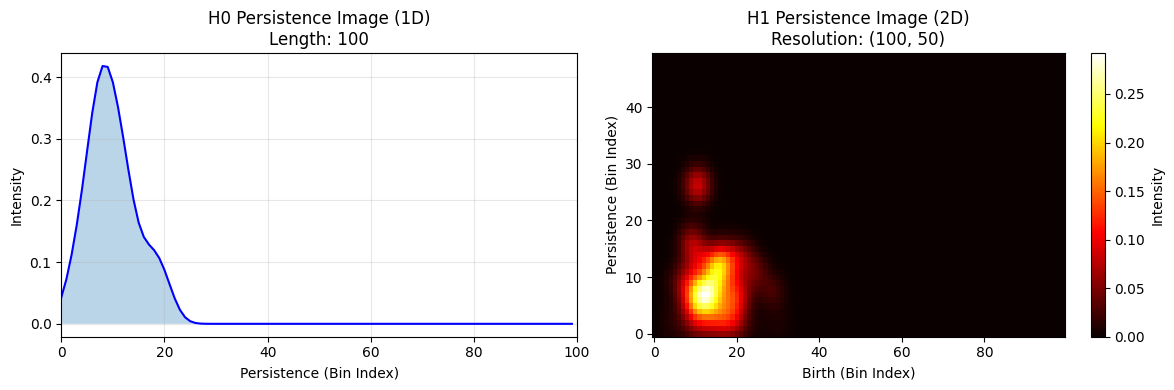

In [12]:
visualize_PIs(PI_six_pack_B_to_A['relative'])